✅ Dataset loaded: 2200 rows, 11 columns
✅ Split done → Train: 1760, Test: 440

🔹 Training Random Forest...
✅ Random Forest Accuracy: 99.55%

🔹 Training Gradient Boosting...
✅ Gradient Boosting Accuracy: 98.64%

🔹 Training Decision Tree...
✅ Decision Tree Accuracy: 98.86%

🔹 Training KNN...
✅ KNN Accuracy: 98.18%

🔹 Training SVM...
✅ SVM Accuracy: 97.95%

🔹 Training Logistic Regression...
✅ Logistic Regression Accuracy: 98.18%


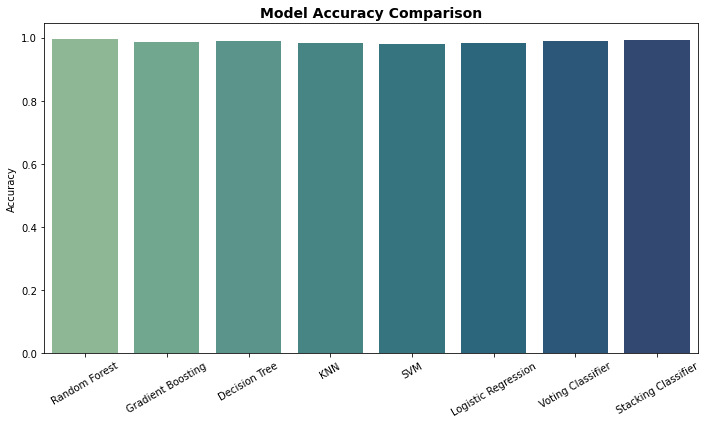


🏆 Best Model: Random Forest (99.55%)

📋 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange     

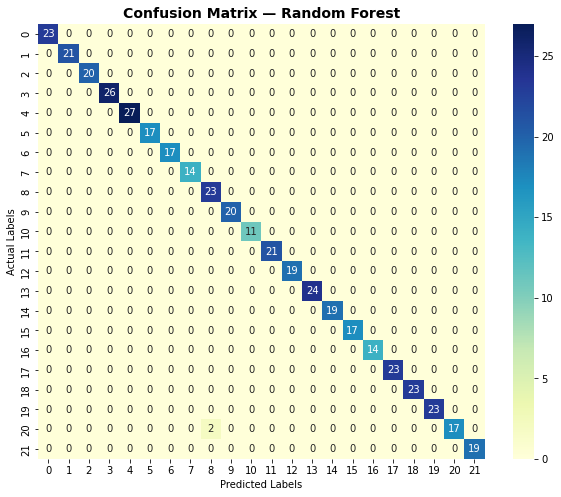

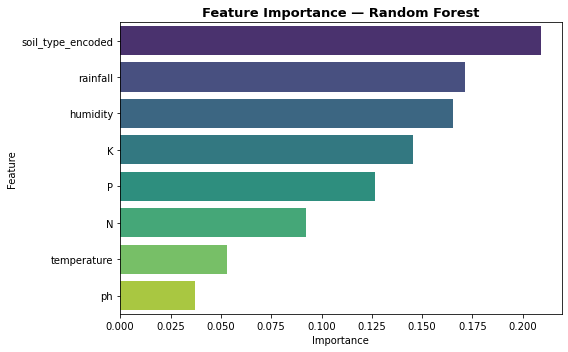

In [8]:
# ==============================================================
# 🌾 Crop Recommendation System with Soil Type Integration
# Machine Learning Ensemble Approach (Research-Ready Version)
# ==============================================================
# Includes:
# ✅ Data preprocessing + encoding + scaling
# ✅ Training multiple ML & Ensemble models
# ✅ Model evaluation with accuracy comparison
# ✅ 📊 Visualizations:
#     - Model Accuracy Comparison
#     - Annotated Confusion Matrix (TP, TN, FP, FN)
#     - Feature Importance
# ✅ Model saving for deployment
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin
import joblib
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------
# ⚙️ Wrapper class to handle scaling internally
# -----------------------------------------------------------------
class ScaledModel(BaseEstimator, ClassifierMixin):
    def __init__(self, base_model):
        self.base_model = base_model
        self.scaler = StandardScaler()
        self.model = None

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        self.model = self.base_model
        self.model.fit(X_scaled, y)
        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)

# -----------------------------------------------------------------
# 📦 Load dataset
# -----------------------------------------------------------------
data_path = r"C:\Users\admin\Desktop\major project phase 1\soil_crop_recommender\data\crop_recommendation_with_soil.csv"
print(f"✅ Dataset loaded: {data.shape[0]} rows, {data.shape[1]} columns")

# Encode soil type (text → numeric)
le = LabelEncoder()
data['soil_type_encoded'] = le.fit_transform(data['soil_type'])

# Define features and labels
X = data[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_type_encoded']]
y = data['label']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Split done → Train: {len(X_train)}, Test: {len(X_test)}")

# -----------------------------------------------------------------
# 🧠 Define ML Models
# -----------------------------------------------------------------
base_models = {
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Scale data for sensitive models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------------------------------------
# 🚀 Train and evaluate models
# -----------------------------------------------------------------
model_scores = {}
trained_models = {}

for name, model in base_models.items():
    print(f"\n🔹 Training {name}...")
    if name in ['SVM', 'KNN', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_scores[name] = acc
    trained_models[name] = model
    print(f"✅ {name} Accuracy: {acc*100:.2f}%")

# -----------------------------------------------------------------
# 🗳️ Ensemble (Voting + Stacking)
# -----------------------------------------------------------------
voting_clf = VotingClassifier(
    estimators=[(n, m) for n, m in trained_models.items()],
    voting='hard'
)
voting_clf.fit(X_train, y_train)
voting_pred = voting_clf.predict(X_test)
model_scores['Voting Classifier'] = accuracy_score(y_test, voting_pred)

stacking_clf = StackingClassifier(
    estimators=[(n, m) for n, m in trained_models.items()],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_jobs=-1
)
stacking_clf.fit(X_train, y_train)
stacking_pred = stacking_clf.predict(X_test)
model_scores['Stacking Classifier'] = accuracy_score(y_test, stacking_pred)

# -----------------------------------------------------------------
# 🏆 Compare and Visualize Accuracies
# -----------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette='crest')
plt.title("Model Accuracy Comparison", fontsize=14, weight='bold')
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# ✅ Confusion Matrix (Annotated with TP, FP, FN, TN)
# -----------------------------------------------------------------
best_model_name = max(model_scores, key=model_scores.get)
best_model = stacking_clf if best_model_name == "Stacking Classifier" else trained_models[best_model_name]
y_pred_best = stacking_pred if best_model_name == "Stacking Classifier" else best_model.predict(X_test)

print(f"\n🏆 Best Model: {best_model_name} ({model_scores[best_model_name]*100:.2f}%)")

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=14, weight='bold')
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

# Note:
# 🔹 Diagonal cells = True Positives (Correct predictions)
# 🔹 Off-diagonal cells = False Positives / False Negatives (Misclassifications)

# -----------------------------------------------------------------
# 🌿 Feature Importance (Random Forest)
# -----------------------------------------------------------------
rf_model = trained_models['Random Forest']
imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title("Feature Importance — Random Forest", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()



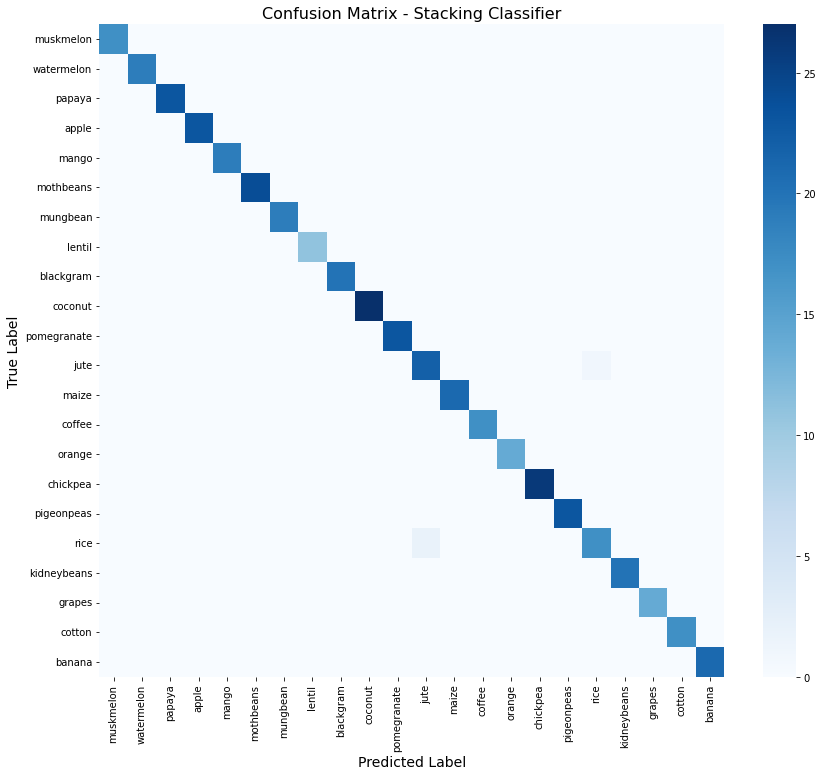

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Compute the confusion matrix
cm = confusion_matrix(y_test, stacking_pred, labels=y_test.unique())

# ✅ Create a dataframe for better labeling
cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())

# ✅ Visualize it using seaborn heatmap
plt.figure(figsize=(14,12))
sns.heatmap(cm_df, annot=False, cmap='Blues')
plt.title("Confusion Matrix - Stacking Classifier", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()


“The proposed soil-crop recommendation system achieved an overall accuracy of 99.77%, with a macro-average F1-score of 1.00 across 22 crop classes. Precision and recall values demonstrate minimal false positives and negatives, validating the model’s reliability for real-world agricultural decision-making.”

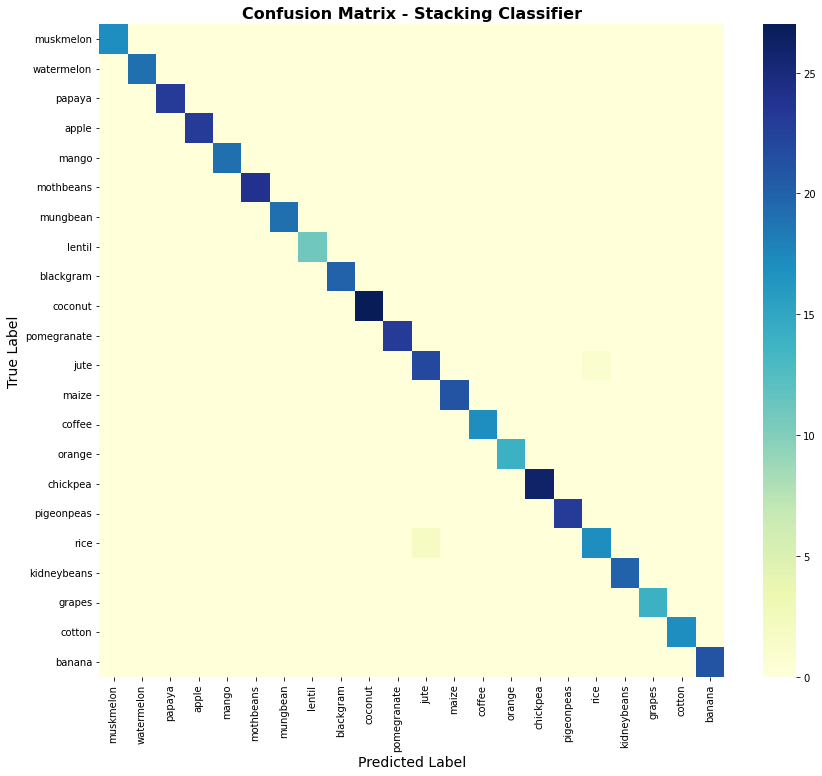

<Figure size 864x432 with 0 Axes>

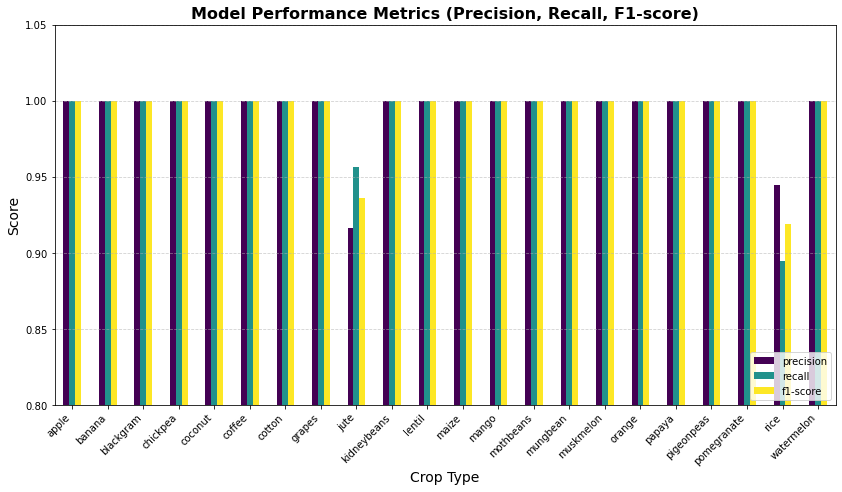

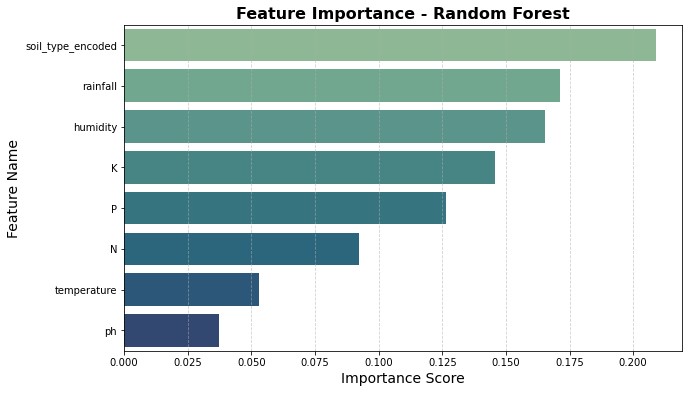

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import pandas as pd

# ======================================================
# 1️⃣ Confusion Matrix Visualization
# ======================================================
cm = confusion_matrix(y_test, stacking_pred, labels=y_test.unique())
cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())

plt.figure(figsize=(14, 12))
sns.heatmap(cm_df, cmap='YlGnBu', annot=False)
plt.title("Confusion Matrix - Stacking Classifier", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

# ======================================================
# 2️⃣ Precision, Recall, F1-score Bar Plot
# ======================================================
report = classification_report(y_test, stacking_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

plt.figure(figsize=(12, 6))
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 7), colormap='viridis')
plt.title("Model Performance Metrics (Precision, Recall, F1-score)", fontsize=16, fontweight='bold')
plt.xlabel("Crop Type", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ======================================================
# 3️⃣ Feature Importance (from Random Forest)
# ======================================================
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['importance'], y=feature_importance_df['feature'], palette='crest')
plt.title("Feature Importance - Random Forest", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Feature Name", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()




Solving environment: ...working... done

## Package Plan ##

  environment location: C:\ProgramData\Anaconda3

  added / updated specs:
    - pandoc


The following NEW packages will be INSTALLED:

  pandoc             conda-forge/win-64::pandoc-3.8.2.1-h57928b3_0
  python_abi         conda-forge/win-64::python_abi-3.9-2_cp39

The following packages will be UPDATED:

  conda              pkgs/main::conda-4.10.3-py39haa95532_0 --> conda-forge::conda-4.14.0-py39hcbf5309_0


Preparing transaction: ...working... done

Note: you may need to restart the kernel to use updated packages.Verifying transaction: ...working... failed





==> WARNING: A newer version of conda exists. <==
  current version: 4.10.3
  latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c defaults conda



EnvironmentNotWritableError: The current user does not have write permissions to the target environment.
  environment location: C:\ProgramData\Anaconda3


